# 02_Data_Collection.ipynb

# GramSathi AI

## Objective

In this notebook, we will collect the geospatial data required for our project.

By the end of this notebook, we will be able to:

* Understand what OpenStreetMap (OSM) is.
* Download map data for a selected village or city.
* Extract the road network.
* Extract buildings.
* Extract schools and hospitals.
* Visualize all collected data on an interactive map.

---

# Why Do We Need Data Collection?

Artificial Intelligence cannot make recommendations without data.

Before predicting where roads or street lights are needed, we must know:

* Where the existing roads are.
* Where people live.
* Where schools and hospitals are located.
* Which areas currently lack infrastructure.

This notebook focuses on collecting that information.

---

# Theory

## What is OpenStreetMap (OSM)?

OpenStreetMap is a free and open-source map of the world.

It contains information about:

* Roads
* Buildings
* Schools
* Hospitals
* Parks
* Rivers
* Bus Stops
* Railway Stations
* Many other public features

Instead of manually creating maps, we can download this information directly using Python.

---

# Libraries Used

## OSMnx

Purpose:
Download and analyze OpenStreetMap data.

---

## GeoPandas

Purpose:
Work with geospatial datasets.

---

## Folium

Purpose:
Create interactive maps.

---

## Pandas

Purpose:
Store and analyze tabular data.

---

## Notebook Workflow

Step 1
Import required libraries.

↓

Step 2
Choose a village or city.

↓

Step 3
Download map data from OpenStreetMap.

↓

Step 4
Extract road network.

↓

Step 5
Extract buildings.

↓

Step 6
Extract schools and hospitals.

↓

Step 7
Display the data on an interactive map.

---

# Expected Output

After completing this notebook, we should have:

* Road network dataset
* Building dataset
* Schools dataset
* Hospitals dataset
* Interactive map visualization

These datasets will be used in the next notebook for GIS analysis and infrastructure gap detection.


In [2]:
!pip install osmnx
!pip install geopandas
!pip install folium
!pip install networkx
!pip install matplotlib

In [3]:
# ==========================================
# GramSathi AI - Data Collection
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import networkx as nx

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Configure OSMnx

ox.settings.use_cache = True
ox.settings.log_console = True

print("✅ OSMnx configured successfully!")

✅ OSMnx configured successfully!


In [8]:
# ==========================================
# GramSathi AI Configuration
# ==========================================

PROJECT_NAME = "GramSathi AI"

COUNTRY = "India"

STATE = "Karnataka"

DISTRICT = "Uttara Kannada"

TALUK = "Karwar"

GRAM_PANCHAYAT = None

VILLAGE = None

PLACE_NAME = f"{TALUK}, {DISTRICT}, {STATE}, {COUNTRY}"

print("=======================================")
print(f"Project      : {PROJECT_NAME}")
print(f"Country      : {COUNTRY}")
print(f"State        : {STATE}")
print(f"District     : {DISTRICT}")
print(f"Taluk        : {TALUK}")
print(f"Study Area   : {PLACE_NAME}")
print("=======================================")

Project      : GramSathi AI
Country      : India
State        : Karnataka
District     : Uttara Kannada
Taluk        : Karwar
Study Area   : Karwar, Uttara Kannada, Karnataka, India


In [9]:
# ==========================================
# Download Study Area Boundary
# ==========================================

study_area = ox.geocode_to_gdf(PLACE_NAME)

study_area

TypeError: Nominatim did not geocode query 'Karwar, Uttara Kannada, Karnataka, India' to a geometry of type (Multi)Polygon.

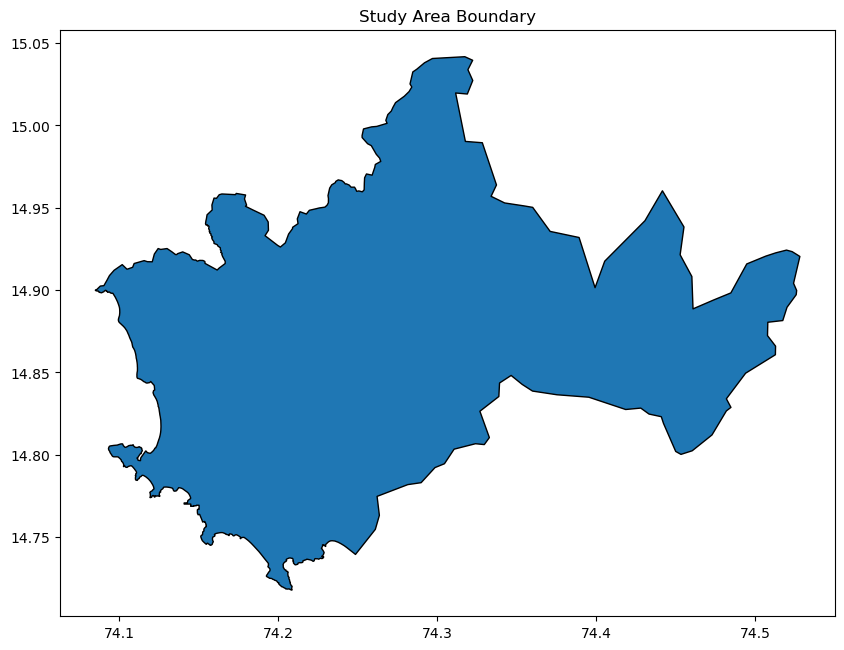

In [7]:
# Plot study area

study_area.plot(figsize=(10, 10), edgecolor="black")

plt.title("Study Area Boundary")

plt.show()

In [10]:
import osmnx as ox

print("OSMnx Version:", ox.__version__)

OSMnx Version: 2.1.0


In [11]:
import osmnx as ox

location = ox.geocode("Karwar, Karnataka, India")

print(location)

(14.812189, 74.1323413)


In [14]:
# ==========================================
# Download Road Network Using Coordinates
# ==========================================

latitude = 14.812189
longitude = 74.1323413

road_network = ox.graph_from_point(
    (latitude, longitude),
    dist=15000,          # 15 km radius
    network_type="drive"
)

print("✅ Road Network Downloaded Successfully!")

✅ Road Network Downloaded Successfully!


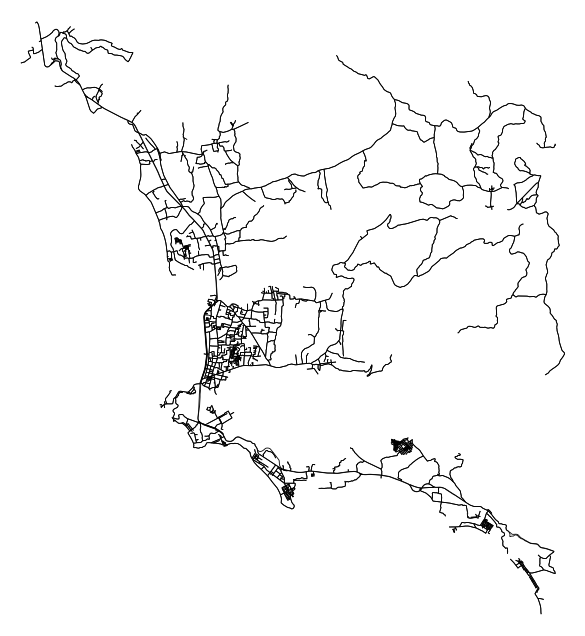

In [15]:
fig, ax = ox.plot_graph(
    road_network,
    bgcolor="white",
    node_size=0,
    edge_color="black",
    edge_linewidth=0.6,
    show=False,
    close=False
)

plt.show()

In [16]:
# ==========================================
# Road Network Statistics
# ==========================================

num_nodes = len(road_network.nodes)
num_edges = len(road_network.edges)

print("========== Road Network Statistics ==========")
print(f"Number of Junctions (Nodes): {num_nodes}")
print(f"Number of Road Segments (Edges): {num_edges}")

========== Road Network Statistics ==========
Number of Junctions (Nodes): 1654
Number of Road Segments (Edges): 3985


In [17]:
# ==========================================
# Convert Graph to GeoDataFrames
# ==========================================

nodes, edges = ox.graph_to_gdfs(road_network)

print("Nodes Shape :", nodes.shape)
print("Edges Shape :", edges.shape)

Nodes Shape : (1654, 4)
Edges Shape : (3985, 14)


In [18]:
# Display the first five road segments

edges.head()

osmid    highway  oneway reversed      length  \
u         v          key                                                      
459895642 1437357973 0    130531802  secondary   False    False   23.926465   
          2587876974 0    252756143      trunk    True    False   21.618649   
          6827206857 0    838172115  secondary   False     True   17.264330   
459895656 459898359  0    252751925    primary    True    False  141.184593   
          2631553817 0    252751930    primary   False    False  958.057782   

                         lanes maxspeed   ref      name  \
u         v          key                                  
459895642 1437357973 0     NaN      NaN   NaN       NaN   
          2587876974 0       2   80; 50  NH66       NaN   
          6827206857 0     NaN      NaN   NaN       NaN   
459895656 459898359  0       2       80   NaN  Old NH16   
          2631553817 0       2       80   NaN  Old NH16   

                                                                   geometry  \
u         v          key                                                      
459895642 1437357973 0     LINESTRING (74.1176 14.87427, 74.11782 14.87426)   
          2587876974 0     LINESTRING (74.1176 14.87427, 74.11775 14.87414)   
          6827206857 0     LINESTRING (74.1176 14.87427, 74.11744 14.87425)   
459895656 459898359  0    LINESTRING (74.1143 14.79168, 74.11422 14.7913...   
          2631553817 0    LINESTRING (74.1143 14.79168, 74.11462 14.7924...   

                         bridge junction access tunnel  
u         v          key                                
459895642 1437357973 0      NaN      NaN    NaN    NaN  
          2587876974 0      NaN      NaN    NaN    NaN  
          6827206857 0      NaN      NaN    NaN    NaN  
459895656 459898359  0      NaN      NaN    NaN    NaN  
          2631553817 0      NaN      NaN    NaN    NaN

In [19]:
# ==========================================
# Save Road Network Data
# ==========================================

nodes.to_file("../datasets/raw/road_nodes.geojson", driver="GeoJSON")
edges.to_file("../datasets/raw/road_edges.geojson", driver="GeoJSON")

print("✅ Road network data saved successfully!")

✅ Road network data saved successfully!


In [20]:
# ==========================================
# Save Complete Road Network Graph
# ==========================================

import osmnx as ox

ox.save_graphml(
    road_network,
    "../datasets/raw/road_network.graphml"
)

print("✅ GraphML file saved successfully!")

✅ GraphML file saved successfully!
